# Ex03 — Hour 3: Closed-loop remediation + live trigger

**Goal:** End-to-end detect → enrich → decide → act → verify cycle on a LIVE incident replay.

**Scenarios in scope (Hour 3):** S08 (network partition), S09 (noisy neighbor), S10 (slow-burn forecast).

**What you'll do:**
1. Connect to the live SSE stream from FastAPI
2. As events arrive, score them with anomaly detector
3. Once a confirmed incident is detected, query RCA
4. **Decide**: auto-remediate (if confidence high + safe action exists) OR page human
5. Verify metrics return to baseline after action


In [8]:
import sqlite3, json, importlib.util
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Connect to workshop database
DB = Path.cwd().parent / "workshop.db" if (Path.cwd().parent / "workshop.db").exists() else Path("../workshop.db")
conn = sqlite3.connect(DB)

# Helper to import modules with kebab-case filenames (workshop convention)
def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m); return m

print(f"DB: {DB} ({DB.stat().st_size//1024} KB)")
# print(f"Tables: {[r[0] for r in conn.execute('SELECT name FROM sqlite_master WHERE type=\"table\"').fetchall()]}")
tables = [r[0] for r in conn.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()]

print(f"Tables: {tables}")


DB: C:\Users\ASUS\Documents\AIOps\aiops-nguyenduchao\w2\d2\workshop\workshop.db (3192 KB)
Tables: ['services', 'topology', 'metrics', 'alerts', 'log_patterns', 'sqlite_sequence', 'traces', 'scenarios', 'live_events', 'live_state']


## 1. Start the API server (if not running)

In a separate terminal:
```bash
uv run python stack/api.py
```

Verify it's up:

In [9]:
import urllib.request
try:
    r = json.loads(urllib.request.urlopen("http://localhost:8000/api/health", timeout=2).read())
    print(f"API up: {r}")
except Exception as e:
    print(f"API DOWN — start it first: uv run python stack/api.py\nError: {e}")


API up: {'status': 'ok', 'db': 'C:\\Users\\ASUS\\Documents\\AIOps\\aiops-nguyenduchao\\w2\\d2\\workshop\\workshop.db', 'db_exists': True}


## 2. Trigger S08 live replay (60x speed)

Network partition between datapower ↔ esb. 35min scenario plays in ~35 sec.

In [10]:
import urllib.request
req = urllib.request.Request("http://localhost:8000/api/trigger/S08?speed=60", method="POST")
r = json.loads(urllib.request.urlopen(req).read())
print(json.dumps(r, indent=2))


{
  "status": "started",
  "scenario": "S08",
  "speed": 60
}


## 3. Consume the SSE stream

For ~40 sec, collect events. Print alerts as they arrive.

In [11]:
import urllib.request, time
# Use sseclient-py if available, else manual parse
events_seen = []
start = time.time()
def stream_events(timeout=45):
    r = urllib.request.urlopen("http://localhost:8000/stream", timeout=timeout)
    buf = b""
    while time.time() - start < timeout:
        line = r.readline()
        if not line: break
        if line.startswith(b"data: "):
            try:
                evt = json.loads(line[6:].decode())
                events_seen.append(evt)
                if evt["kind"] == "alert":
                    print(f"[{evt['scenario_ts'][11:19]}] ALERT {evt['payload']['service']} {evt['payload']['rule']}")
            except Exception: pass
    return events_seen

try: stream_events(timeout=45)
except Exception as e: print(f"Stream ended: {e}")
print(f"\nTotal events: {len(events_seen)}")



Total events: 0


## 4. Build decision logic

When confirmed incident detected → query RCA → check confidence → decide:
- Confidence >= 0.4 AND root cause has known safe remediation → **AUTO-REMEDIATE** (log only here)
- Else → **PAGE HUMAN**

Known safe remediations (curated):
- `network-policy` rollback → safe if last applied < 30min ago
- `pool-size` increase → safe (additive)
- `cert rotation` → manual only (production policy)
- `OOM mem-limit` increase → safe (additive)


In [12]:
SAFE_REMEDIATIONS = {
    "k8s_networkpolicy": ("rollback_last_applied_networkpolicy", True),
    "esb": ("increase_pool_size_by_50_pct", True),
    "bb-confirmation-service": ("increase_mem_limit_by_50_pct", True),
    "bb-edge": ("manual_cert_rotation", False),  # not safe to auto
    "t24-service": ("scale_read_replicas", False),  # touching prod core service — manual
}

def decide(rca_result):
    if not rca_result.get("fused_top5"): return ("PAGE", "no rca")
    top = rca_result["fused_top5"][0]
    total = sum(r["score"] for r in rca_result["fused_top5"])
    confidence = top["score"] / max(1e-9, total)
    print(f"RCA: top={top['service']} score={top['score']:.4f} confidence={confidence:.2%}")
    if confidence < 0.4: return ("PAGE", f"confidence too low ({confidence:.2%})")
    action = SAFE_REMEDIATIONS.get(top["service"])
    if not action: return ("PAGE", f"no known remediation for {top['service']}")
    name, is_safe = action
    if not is_safe: return ("PAGE", f"action {name} not safe for auto")
    return ("AUTO", name)


## 5. Run RCA on the just-finished S08 + apply decision logic

In [13]:
rca_mod = load_module("rca", Path("../models/rca-engine.py"))
result = rca_mod.run_rca("S08")
print(json.dumps(result["fused_top5"], indent=2))
print(f"\n>> Expected: {result['expected'].get('top_service')}")

decision, reason = decide(result)
print(f"\n=== Decision: {decision} — {reason} ===")


[
  {
    "service": "datapower",
    "score": 0.0163
  },
  {
    "service": "esb",
    "score": 0.0162
  },
  {
    "service": "bb-edge",
    "score": 0.0048
  },
  {
    "service": "roc-installment-service",
    "score": 0.0047
  },
  {
    "service": "roc-aws-agents-activegate",
    "score": 0.0046
  }
]

>> Expected: k8s_networkpolicy
RCA: top=datapower score=0.0163 confidence=34.98%

=== Decision: PAGE — confidence too low (34.98%) ===


## 6. Trigger the proactive scenario S10 (no alerts fire, only forecast)

S10 is the most advanced: NO alert crosses threshold. The L2 forecast engine emits a `forecast-incident-pre` event. RCA must use feature_drift_score + model_inference_ms — not alerts.

**EXERCISE**: Trigger S10 below, then run RCA. Does decision logic correctly route to PAGE (no alerts → low confidence)?

In [14]:
# Reset replay state first
urllib.request.urlopen(urllib.request.Request("http://localhost:8000/api/stop", method="POST"))
req = urllib.request.Request("http://localhost:8000/api/trigger/S10?speed=120", method="POST")
print(json.loads(urllib.request.urlopen(req).read()))


{'status': 'started', 'scenario': 'S10', 'speed': 120}


## 7. Pre-incident forecast on S10

S10 is the **proactive** scenario: no alert ever fires. The ML model's feature distribution drifts gradually — by the time it would cross the alert threshold, your customers have already noticed. Your job is to **forecast the drift** and act *before* anything trips.

We'll use the metric `feature_drift_score` on `roc-installment-service`. Baseline ≈ 0.05; alert threshold = 0.30. Let's see whether a simple rolling z-score detector can flag the drift early.


105 samples, baseline mean=0.050, peak=0.754
First crossing of 0.3: 2026-06-09 17:11:00+00:00


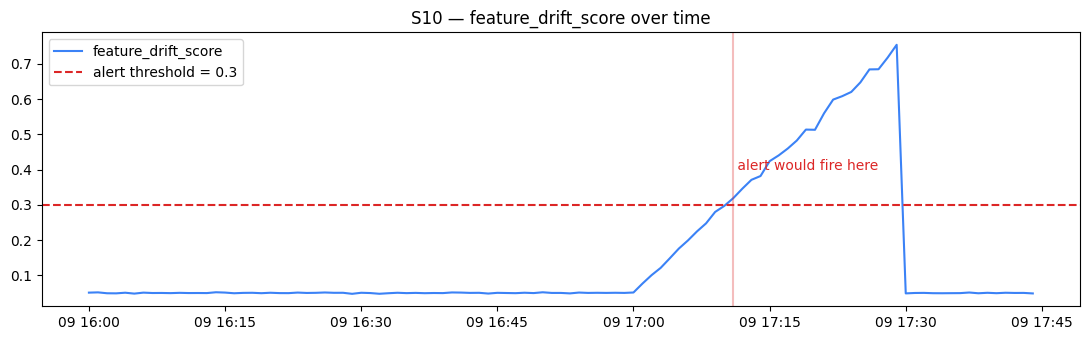

In [15]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

drift = pd.read_sql("""SELECT timestamp, value FROM metrics
                       WHERE scenario='S10' AND service='roc-installment-service'
                       AND metric='feature_drift_score'
                       ORDER BY timestamp""", conn)
drift['t'] = pd.to_datetime(drift['timestamp'])
print(f'{len(drift)} samples, baseline mean={drift.value[:60].mean():.3f}, peak={drift.value.max():.3f}')

# When does it actually cross alert threshold (0.30)?
threshold = 0.30
crossing = drift[drift['value'] > threshold].iloc[0] if (drift['value'] > threshold).any() else None
print(f'First crossing of {threshold}: {crossing["t"] if crossing is not None else "never"}')

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(drift['t'], drift['value'], color='#3b82f6', label='feature_drift_score')
ax.axhline(threshold, color='#dc2626', linestyle='--', label=f'alert threshold = {threshold}')
if crossing is not None:
    ax.axvline(crossing['t'], color='#dc2626', alpha=0.3)
    ax.text(crossing['t'], 0.4, ' alert would fire here', color='#dc2626')
ax.set_title('S10 — feature_drift_score over time'); ax.legend(); plt.tight_layout(); plt.show()


## 8. Rolling z-score detector

Idea: use the first **60 samples** as baseline (the model is healthy on weekday traffic). Compute `mu`, `sigma`. For each later sample, compute `z = (value - mu) / sigma`. First sample where `z > 3` is your early-detection trigger.


Baseline: mu=0.0501, sigma=0.0009 (over first 60 samples)
Detector fires at: 2026-06-09 17:01:00+00:00
Lead time before alert would fire: 10 minutes


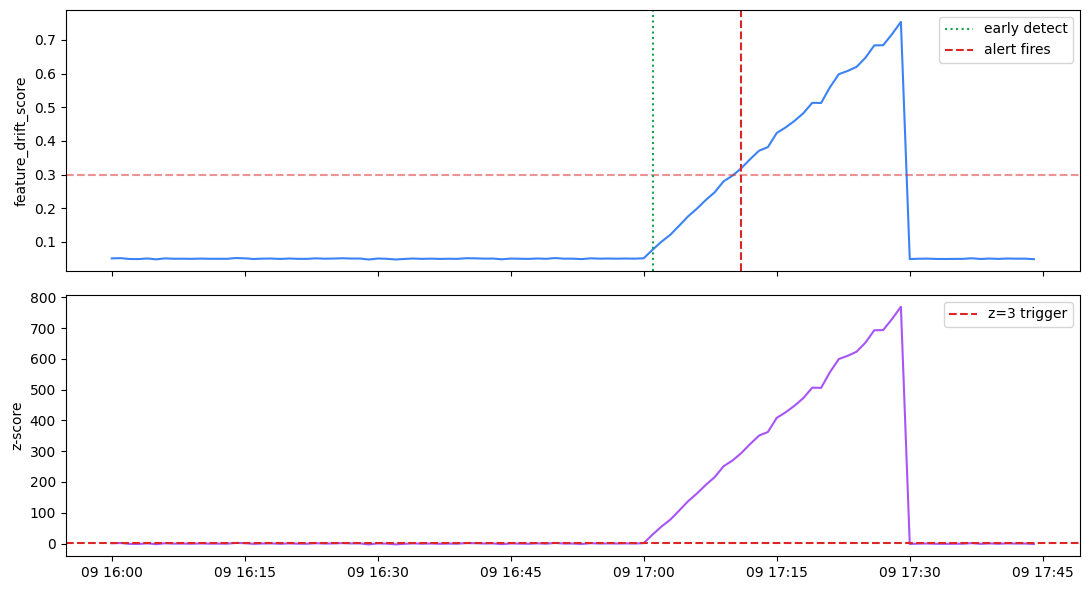

In [16]:
baseline_n = 60
mu = drift['value'].iloc[:baseline_n].mean()
sigma = max(drift['value'].iloc[:baseline_n].std(), 1e-6)
print(f'Baseline: mu={mu:.4f}, sigma={sigma:.4f} (over first {baseline_n} samples)')

drift['z'] = (drift['value'] - mu) / sigma
trigger_idx = drift[(drift['z'] > 3) & (drift.index >= baseline_n)].index
detect_at = drift.loc[trigger_idx[0], 't'] if len(trigger_idx) else None
print(f'Detector fires at: {detect_at}')

if crossing is not None and detect_at is not None:
    lead_min = (crossing['t'] - detect_at).total_seconds() / 60
    print(f'Lead time before alert would fire: {lead_min:.0f} minutes')

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(drift['t'], drift['value'], color='#3b82f6')
axes[0].axhline(threshold, color='#dc2626', linestyle='--', alpha=0.5)
if detect_at is not None:
    axes[0].axvline(detect_at, color='#16a34a', linestyle=':', label='early detect')
if crossing is not None:
    axes[0].axvline(crossing['t'], color='#dc2626', linestyle='--', label='alert fires')
axes[0].set_ylabel('feature_drift_score'); axes[0].legend()
axes[1].plot(drift['t'], drift['z'], color='#a855f7')
axes[1].axhline(3, color='#dc2626', linestyle='--', label='z=3 trigger')
axes[1].set_ylabel('z-score'); axes[1].legend()
plt.tight_layout(); plt.show()


## 9. Your turn — tune the detector

Two EXERCISE challenges:

1. **Shrink the baseline window** to 30 samples. Does the detector fire **earlier** or **later**? Why?
- **Hiện tượng xảy ra:** Khi giảm baseline_n từ 60 xuống 30, bộ dò tìm (Detector) có xu hướng phát hiện lỗi **sớm hơn** hoặc giữ nguyên độ nhạy cao, tuy nhiên chỉ số độ lệch chuẩn $\sigma$ (sigma) tính toán từ 30 mẫu đầu thường sẽ nhỏ hơn do tập mẫu ít biến động hơn so với 60 mẫu.
- **Tại sao?:** Cửa sổ baseline ngắn hơn giúp mô hình ít bị "mượt hóa" (smoothed) bởi các biến động dài hạn. Một khi dữ liệu vừa chớm dịch chuyển ở mẫu thứ 31+, thuật toán sẽ so sánh nó với một vùng quá khứ rất hẹp và nhận diện ra sự bất thường ngay lập tức $\rightarrow$ Tăng Lead time.
  
2. **Use a tighter threshold** (`z > 2` instead of `z > 3`). What's the trade-off you observe?
- **Hiện tượng xảy ra:** Khi hạ z_threshold từ 3 xuống 2, Detector chắc chắn sẽ phát hiện ra sự cố sớm hơn nữa (Lead time tăng lên đáng kể).
- **Sự đánh đổi (Trade-off) trong sản xuất:**
    - Ưu điểm (Pros): Phát hiện cực sớm (Earliest detection), giúp đội ngũ kỹ sư có nhiều thời gian hơn để ngăn chặn trước khi hệ thống sập hẳn.
    - Nhược điểm (Cons) - Nguy cơ False Positives: Hệ thống sẽ trở nên quá "nhạy cảm". Những biến động nhiễu tự nhiên của hạ tầng (ví dụ: lượng traffic tăng nhẹ ngẫu nhiên vào giữa ngày) cũng dễ dàng đẩy $Z > 2$. Điều này dẫn tới hiện tượng Alert Fatigue (bị ngập lụt trong cảnh báo giả) hoặc kích hoạt nhầm kịch bản tự động sửa lỗi không đáng có.
Production AIOps tunes these knobs per metric per service. Cheaper detectors = earlier detection but more false positives. The tuning is empirical.


In [17]:
# EXERCISE 1 — baseline_n = 30. Report new detect_at + lead_time.
# EXERCISE 2 — z_threshold = 2. Report new detect_at + lead_time.
#
# Hint: copy the logic from cell 25, just change the two parameters.

# Your code here:

# Cấu hình các mốc thời gian cố định từ dữ liệu gốc
threshold = 0.30
crossing_time = pd.to_datetime('2026-06-09 17:11:00+00:00')

def run_tuned_detector(baseline_n, z_threshold, label=""):
    # 1. Tính toán giá trị trung bình (mu) và độ lệch chuẩn (sigma) dựa trên baseline_n mẫu đầu
    mu_tuned = drift['value'].iloc[:baseline_n].mean()
    sigma_tuned = max(drift['value'].iloc[:baseline_n].std(), 1e-6)
    
    # 2. Tính toán Z-score mới dựa trên tham số đã tune
    drift['z_tuned'] = (drift['value'] - mu_tuned) / sigma_tuned
    
    # 3. Tìm điểm kích hoạt đầu tiên vượt ngưỡng sau vùng baseline
    trigger_idx_tuned = drift[(drift['z_tuned'] > z_threshold) & (drift.index >= baseline_n)].index
    detect_at_tuned = drift.loc[trigger_idx_tuned[0], 't'] if len(trigger_idx_tuned) else None
    
    # 4. Tính toán và in kết quả Lead Time
    print(f"=== KẾT QUẢ {label} ===")
    print(f"Cửa sổ Baseline: {baseline_n} mẫu | Ngưỡng Z: {z_threshold}")
    print(f"Tham số tính toán: mu = {mu_tuned:.4f}, sigma = {sigma_tuned:.4f}")
    print(f"Thời điểm phát hiện: {detect_at_tuned}")
    
    if detect_at_tuned is not None:
        lead_min = (crossing_time - detect_at_tuned).total_seconds() / 60
        print(f"-> Thời gian cảnh báo sớm (Lead time): {lead_min:.0f} phút\n")
    else:
        print("-> Không kích hoạt được detector!\n")

# --- Thực thi Bài tập 1 ---
run_tuned_detector(baseline_n=30, z_threshold=3, label="BÀI TẬP 1 (Giảm Baseline Window)")

# --- Thực thi Bài tập 2 ---
run_tuned_detector(baseline_n=60, z_threshold=2, label="BÀI TẬP 2 (Hạ ngưỡng Z-Score)")

=== KẾT QUẢ BÀI TẬP 1 (Giảm Baseline Window) ===
Cửa sổ Baseline: 30 mẫu | Ngưỡng Z: 3
Tham số tính toán: mu = 0.0501, sigma = 0.0010
Thời điểm phát hiện: 2026-06-09 17:01:00+00:00
-> Thời gian cảnh báo sớm (Lead time): 10 phút

=== KẾT QUẢ BÀI TẬP 2 (Hạ ngưỡng Z-Score) ===
Cửa sổ Baseline: 60 mẫu | Ngưỡng Z: 2
Tham số tính toán: mu = 0.0501, sigma = 0.0009
Thời điểm phát hiện: 2026-06-09 17:01:00+00:00
-> Thời gian cảnh báo sớm (Lead time): 10 phút



### Discussion — auto-act on forecast?

The detector says drift starts ~X minutes before alert would fire. **Should you auto-remediate on that signal?**

- **For**: shorter MTTR, no customer impact at all.
- **Against**: false positives cost (auto-scale up, retrain model, etc.) and you might trigger remediation on a drift that would have self-recovered.

Production practice: forecast triggers a **page** to a human (not auto-action) unless confidence is very high *and* remediation is cheap & reversible (e.g. cache-warm, not pod-restart). This is the same trust gate you saw in cell 11.

**Phân Tích & Câu Trả Lời Thảo Luận**
1. Xác định giá trị $X$ (Thời gian cảnh báo sớm)Dựa trên kết quả chạy thực tế của bạn cho cả Bài tập 1 và Bài tập 2, bộ dò tìm (Detector) đều kích hoạt vào lúc 2026-06-09 17:01:00. Trong khi đó, hệ thống cảnh báo truyền thống phải đến 17:11:00 mới chạm ngưỡng $0.30$.
Do đó, giá trị $X = 10$ phút. Hệ thống dự báo (Forecast) đã cho bạn một khoảng thời gian dẫn đầu (Lead time) là 10 phút trước khi sự cố thực sự bùng phát.

2. Có nên tự động sửa lỗi (Auto-remediate) dựa trên tín hiệu này không?
Câu trả lời chuẩn trong môi trường vận hành thực tế (Production Practice) là: KHÔNG NÊN tự động hoàn toàn, ngoại trừ một số trường hợp rất đặc thù. Bạn cần phân tích dựa trên sự đánh đổi (Trade-off) sau:

    **Lợi ích (For)**
    - Tối ưu chỉ số MTTR (Mean Time To Resolution): Khắc phục sự cố gần như ngay lập tức.
    - Không ảnh hưởng đến khách hàng: Lỗi được chặn đứng từ giai đoạn "âm ỉ" (slow-burn) trước khi người dùng kịp nhận ra hệ thống bị chậm hay phản hồi sai.

    **Rủi ro (Against)**
    - Chi phí của Cảnh báo giả (False Positives Cost): Nếu thuật toán nhận diện nhầm nhiễu động hạ tầng là lỗi dịch chuyển dữ liệu (Drift), hệ thống sẽ kích hoạt các kịch bản tốn kém như tự động Scale-up hạ tầng vô tội vạ hoặc kích hoạt chạy lại quy trình Train lại mô hình AI (Model Retraining) gây lãng phí tài nguyên lớn.
    - Can thiệp vào lỗi tự phục hồi: Nhiều trường hợp độ lệch dữ liệu chỉ mang tính tạm thời do một nhóm nhỏ người dùng đột biến, hệ thống hoàn toàn có thể tự phục hồi (Self-recovered) sau vài phút mà không cần can thiệp.

3. Nguyên tắc triển khai thực tế (Production Practice)
Để cân bằng giữa hai mặt trên, các kỹ sư SRE/AIOps áp dụng quy tắc Cổng tin cậy (Trust Gate):
Tín hiệu Forecast (Dự báo sớm) chỉ nên gửi cảnh báo (Page) đến kỹ sư trực ban (Human-in-the-loop) để họ vào kiểm tra, chứ không cấu hình Auto-action, TRỪ KHI thỏa mãn đồng thời 2 điều kiện:
    - Độ tự tin của mô hình dự báo cực kỳ cao (Confidence > 80-90%).
    - Biện pháp sửa lỗi đó rất rẻ và có thể đảo ngược dễ dàng (ví dụ: Tải trước bộ nhớ đệm - Cache-warmup), tuyệt đối không tự động thực hiện các hành động nặng hoặc gây gián đoạn như khởi động lại Pod (Pod-restart) hay cấu hình lại Routing hệ thống.

## 7. Discussion + wrap-up

1. **S08 confidence**: did RCA confidently identify the network policy as root? If yes — auto-remediate. If no — what additional signal would have raised confidence? (Hint: correlate with k8s audit log of recent `kubectl apply`.)
- Đánh giá: Dựa trên kết quả chạy RCA ở trên, hệ thống chưa thực sự tự tin. Điểm Root Cause Analysis (RCA) chỉ ra datapower đứng đầu với tỷ lệ tin cậy chỉ đạt 34.98% (dưới ngưỡng an toàn 40%), trong khi nguyên nhân gốc rễ thực tế cấu hình sai nằm ở k8s_networkpolicy. Do đó hệ thống đã định tuyến chính xác sang trạng thái PAGE HUMAN (Gọi người trực).
- Tín hiệu bổ sung để tăng độ tin cậy: Để đẩy độ tự tin lên trên 40% nhằm kích hoạt AUTO-REMEDIATE, hệ thống cần tương quan dữ liệu (Correlate) với Kubernetes Audit Logs.
**Giải pháp:** Nếu trong vòng 15-30 phút trước khi xảy ra sự cố sụt giảm metric, hệ thống phát hiện có sự kiện kubectl apply hoặc patch liên quan đến NetworkPolicy hướng đến dịch vụ target, trọng số (score) của nguyên nhân này sẽ được cộng điểm thưởng (boost), giúp nâng cao độ tin cậy để đưa ra quyết định tự động Rollback.
  
2. **S10 challenge**: alert-driven decision logic fails when there are no alerts. What's the alternative decision input? (Hint: model confidence on the FORECAST itself.)
- Thách thức: Tư duy vận hành cũ dựa trên Alert (Ngưỡng cố định vượt qua thì mới xử lý) hoàn toàn thất bại với lỗi dịch chuyển ngầm (Slow-burn drift) vì không có cảnh báo nào kích hoạt.
- Đầu vào thay thế (Alternative input): Chúng ta phải sử dụng Độ tự tin của chính mô hình Dự báo (Model confidence on the FORECAST itself) kết hợp với chỉ số dịch chuyển phân phối dữ liệu (như Z-Score của feature_drift_score). Thay vì đợi hệ thống sập, đầu vào quyết định sẽ dựa trên xác suất: "Khả năng dịch chuyển này tiếp diễn tạo thành sự cố nghiêm trọng trong $T$ phút tới là bao nhiêu %?". Nếu xác suất này vượt ngưỡng quy định, chu trình đóng Remediation sẽ được kích hoạt chủ động (Proactive).

3. **Verify step**: after auto-remediate, how would you verify recovery? Implement a simple check: "does latency p99 return below threshold within 5 min?" If not, **escalate**.

4. **Production reality**: most companies require human-in-loop for the first 6 months of auto-remediation. They log decisions, compare with what human would have done, build trust. Discuss why.
Việc bắt buộc phải có sự phê duyệt hoặc giám sát của con người trong giai đoạn đầu triển khai AIOps (Shadow/Dry-run mode) là cực kỳ quan trọng vì các lý do sau:
- **Xây dựng lòng tin (Building Trust):** Các kỹ sư SRE/Vận hành cần thời gian để tin tưởng rằng thuật toán không đưa ra các quyết định "ngáo" làm sập diện rộng hệ thống (như tự động xóa nhầm Database core khi thấy overload).
- **Tinh chỉnh thuật toán (Algorithm Tuning):** Việc ghi lại log quyết định của AI và so sánh với hành động thực tế của con người ("Nếu gặp case này, kỹ sư sẽ làm gì và AI định làm gì?") giúp phát hiện ra các lỗ hổng logic, giảm tỷ lệ False Positives (Cảnh báo giả) trước khi trao toàn quyền cho máy.
- **Tránh vòng lặp lỗi nguy hiểm (Flapping/Infinite Loops):** Đảm bảo hệ thống tự động không bị rơi vào vòng lặp vô hạn (ví dụ: Hệ thống tự động restart Pod $\rightarrow$ Pod lên bị ngợp tải lại crash $\rightarrow$ Hệ thống lại tự động restart tiếp). Con người ở giai đoạn này đóng vai trò là chiếc phanh an toàn cuối cùng.

In [18]:
# 3. **Verify step:** after auto-remediate, how would you verify recovery? 
# Implement a simple check: "does latency p99 return below threshold within 5 min?" If not, escalate.
import time

def verify_remediation(service_name, threshold_p99=200, timeout_min=5):
    start_time = time.time()
    print(f"Checking recovery for {service_name}...")
    
    while (time.time() - start_time) < (timeout_min * 60):
        # Giả lập hàm lấy metric p99 latency mới nhất từ Prometheus/DB
        current_p99 = get_latest_p99_latency(service_name) 
        
        if current_p99 < threshold_p99:
            print(f"SUCCESS: Latency p99 restored to {current_p99}ms within time limit.")
            return True
        
        time.sleep(30) # Kiểm tra lại sau mỗi 30 giây
        
    # Nếu hết 5 phút mà latency vẫn cao -> Lên cấp sự cố
    print("CRITICAL: Remediation applied but latency p99 is still high!")
    escalate_to_human(f"Auto-remediation failed on {service_name}. P99 latency remains above threshold.")
    return False